In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix,
                              precision_recall_curve, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42

In [3]:
df = pd.read_csv("spambase_csv.csv")
df.rename(columns={df.columns[-1]: "class"}, inplace=True)
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [4]:
print("Total missing values in the dataset:", df.isnull().sum().sum())

if df.isnull().sum().sum() > 0:
    df = df.fillna(df.mean(numeric_only=True))
    print("Missing values were filled using column mean.")
else:
    print("No missing values found, dataset is clean.")

duplicates = df.duplicated().sum()
print("Duplicate rows found:", duplicates)

Total missing values in the dataset: 0
No missing values found, dataset is clean.
Duplicate rows found: 391


C:\Users\sayed\AppData\Local\Temp\ipykernel_18780\117571114.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class", data=df, palette=["#4C72B0", "#DD8452"])


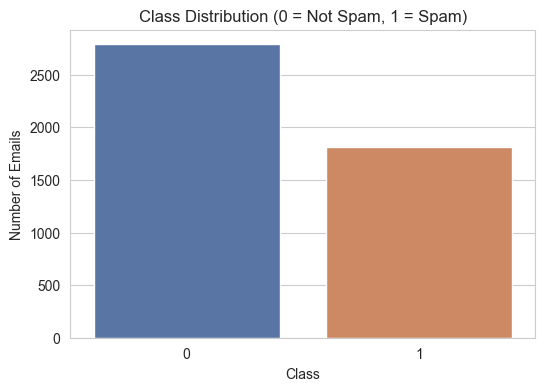

class
0    60.595523
1    39.404477
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x="class", data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Class Distribution (0 = Not Spam, 1 = Spam)")
plt.xlabel("Class")
plt.ylabel("Number of Emails")
plt.show()

print(df["class"].value_counts(normalize=True) * 100)

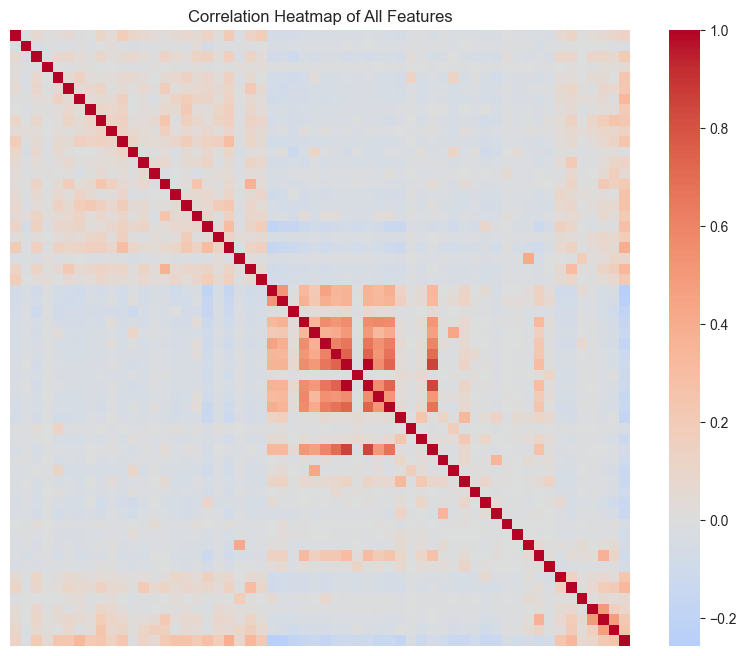

In [6]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)
plt.title("Correlation Heatmap of All Features")
plt.show()

Top Features:
['word_freq_remove', 'word_freq_free', 'word_freq_you', 'word_freq_your', 'word_freq_000', 'char_freq_%24']


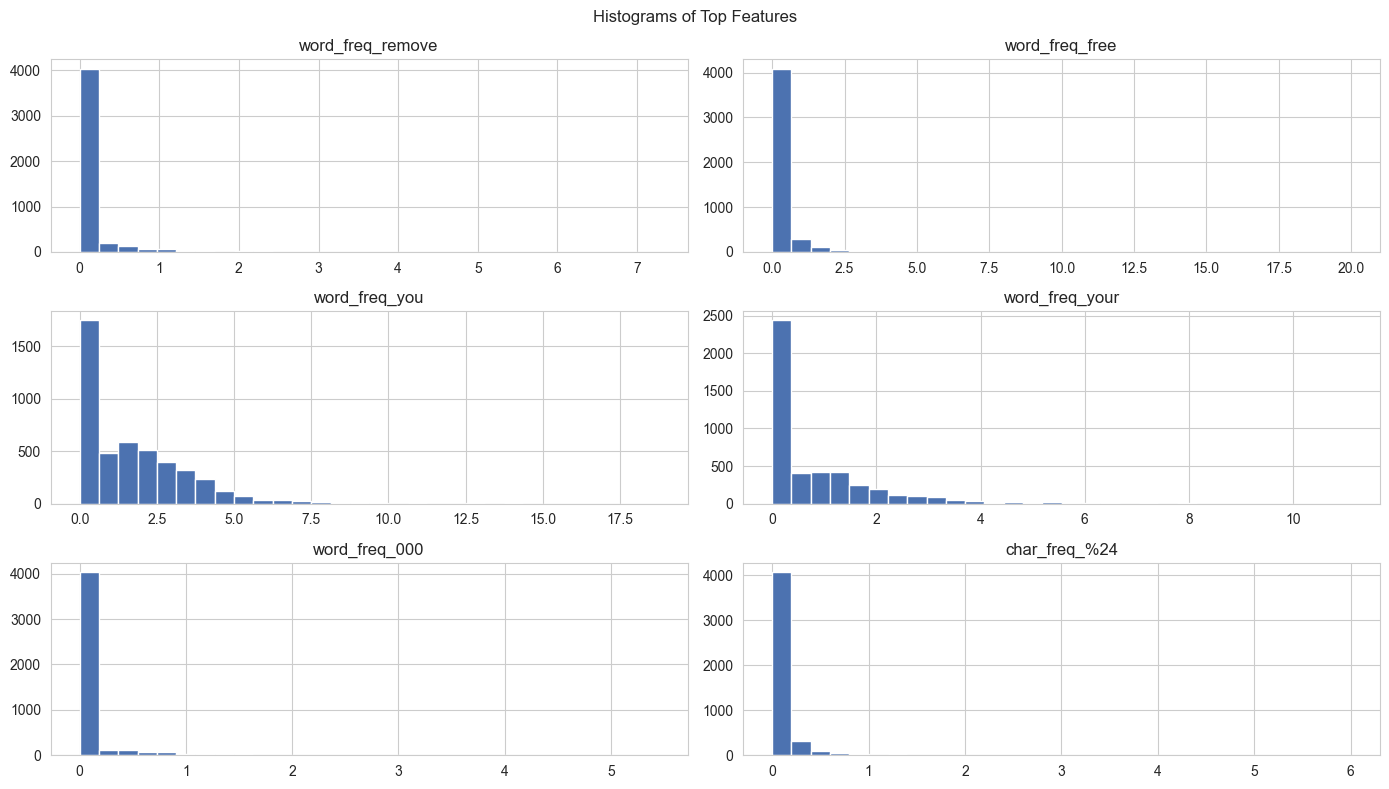

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2

X = df.drop("class", axis=1)
y = df["class"]

selector = SelectKBest(score_func=f_classif, k=6)
# selector = SelectKBest(score_func=chi2, k=6)
selector.fit(X, y)

important_features = X.columns[selector.get_support()].tolist()

print("Top Features:")
print(important_features)

df[important_features].hist(figsize=(14,8), bins=30, color="#4C72B0")
plt.suptitle("Histograms of Top Features")
plt.tight_layout()
plt.show()

C:\Users\sayed\AppData\Local\Temp\ipykernel_18780\997570749.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="class", y=feature, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
C:\Users\sayed\AppData\Local\Temp\ipykernel_18780\997570749.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="class", y=feature, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
C:\Users\sayed\AppData\Local\Temp\ipykernel_18780\997570749.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="class", y=feature, data=df, ax=axes[i], palette=["#4C72B0"

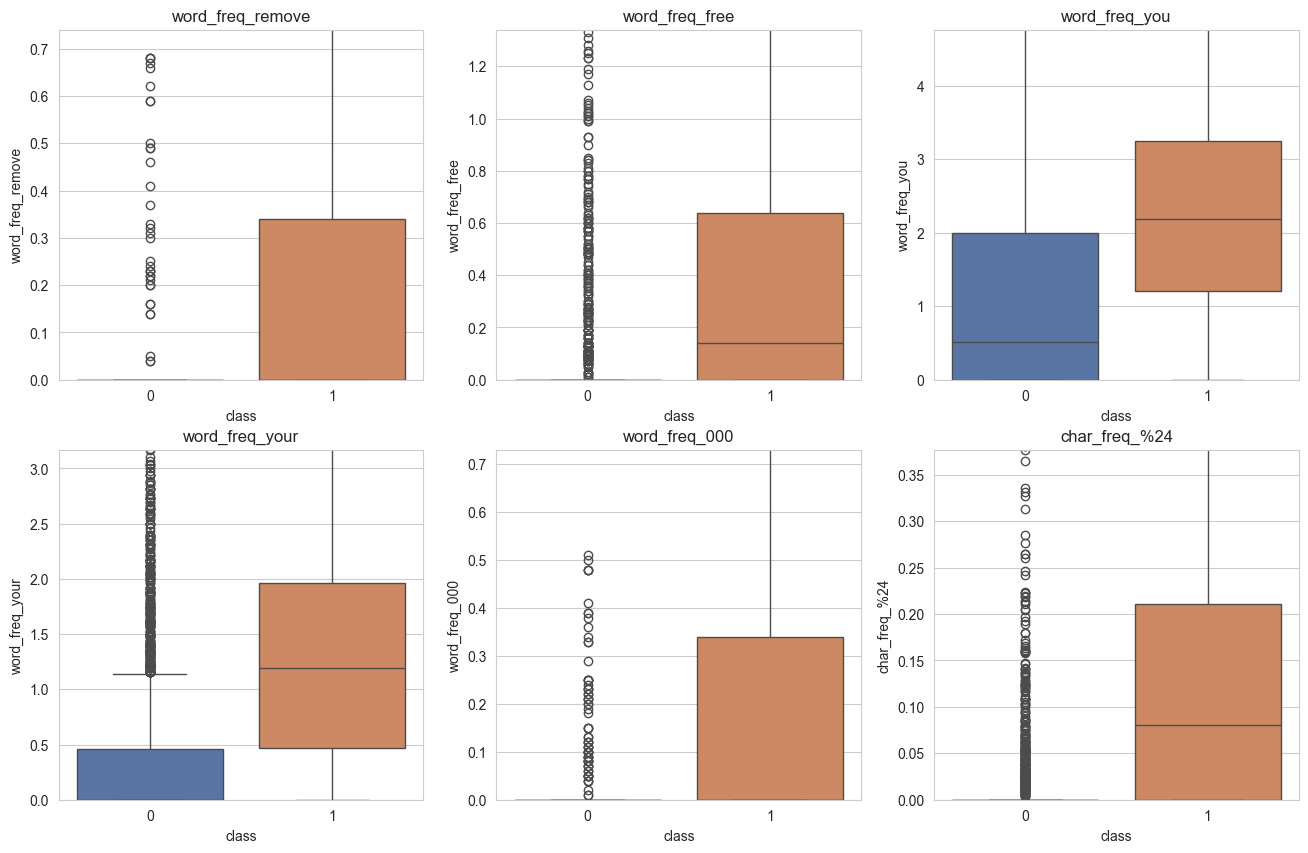

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, feature in enumerate(important_features):
    sns.boxplot(x="class", y=feature, data=df, ax=axes[i], palette=["#4C72B0", "#DD8452"])
    axes[i].set_title(feature)
    axes[i].set_ylim(0, df[feature].quantile(0.95))
plt.show()

In [9]:
X = df.drop(columns=["class"])
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Standard scaling
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Min-Max scaling 
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (3450, 57)  Test shape: (1151, 57)


In [10]:
models = {}
train_times = {}

start = time.time()
gnb = GaussianNB()
gnb.fit(X_train_std, y_train)
train_times["GaussianNB"] = time.time() - start
models["GaussianNB"] = (gnb, X_test_std)

start = time.time()
mnb = MultinomialNB()
mnb.fit(X_train_mm, y_train)
train_times["MultinomialNB"] = time.time() - start
models["MultinomialNB"] = (mnb, X_test_mm)

start = time.time()
bnb = BernoulliNB()
bnb.fit(X_train_std, y_train)
train_times["BernoulliNB"] = time.time() - start
models["BernoulliNB"] = (bnb, X_test_std)

start = time.time()
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_std, y_train)
train_times["KNN"] = time.time() - start
models["KNN"] = (knn, X_test_std)

print("Models trained:", list(models.keys()))
print("Training times (seconds):", train_times)

Models trained: ['GaussianNB', 'MultinomialNB', 'BernoulliNB', 'KNN']
Training times (seconds): {'GaussianNB': 0.010816335678100586, 'MultinomialNB': 0.008262872695922852, 'BernoulliNB': 0.00500035285949707, 'KNN': 0.0024907588958740234}


In [11]:
def evaluate_model(name, model, X_te, y_te):
    start = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - start

    y_proba = model.predict_proba(X_te)[:, 1]

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1-score": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_proba),
        "Prediction Time (s)": pred_time,
    }
    return results, y_pred, y_proba

results_list = []
predictions = {}  

for name, (model, X_te) in models.items():
    res, y_pred, y_proba = evaluate_model(name, model, X_te, y_test)
    results_list.append(res)
    predictions[name] = (y_pred, y_proba)

results_df = pd.DataFrame(results_list).set_index("Model")
results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC,Prediction Time (s)
Model,,,,,,
GaussianNB,0.825369,0.707718,0.949339,0.810913,0.936771,0.002705
MultinomialNB,0.900087,0.947230,0.790749,0.861945,0.961433,0.000437
BernoulliNB,0.904431,0.911483,0.839207,0.873853,0.962285,0.001410
KNN,0.899218,0.878924,0.863436,0.871111,0.950853,0.576006


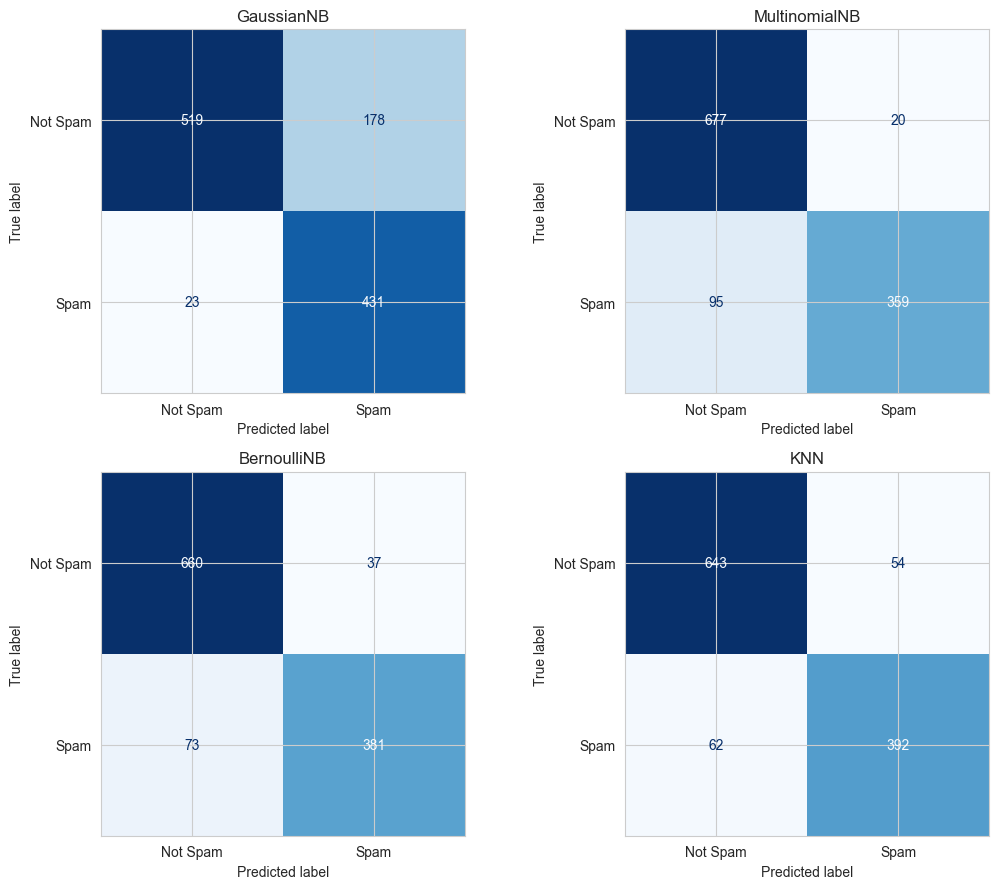

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for ax, (name, (y_pred, y_proba)) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Spam", "Spam"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.show()

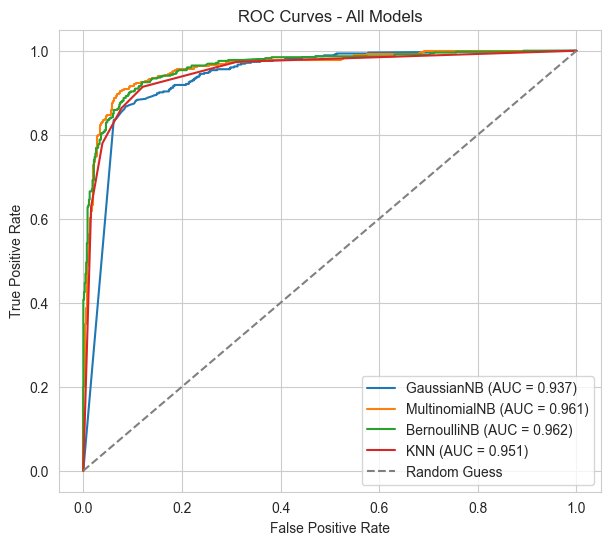

In [13]:
plt.figure(figsize=(7, 6))
for name, (y_pred, y_proba) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models")
plt.legend()
plt.show()

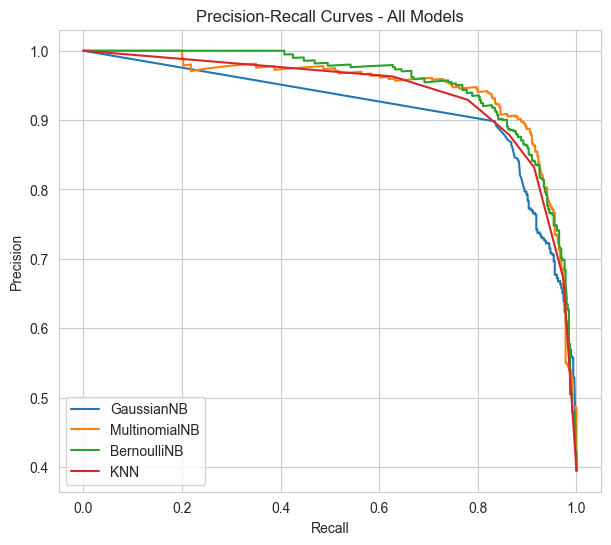

In [14]:
plt.figure(figsize=(7, 6))
for name, (y_pred, y_proba) in predictions.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - All Models")
plt.legend()
plt.show()

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

k_values = list(range(1, 31, 2))

results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_std, y_train)

    y_pred = knn.predict(X_test_std)

    results.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df = results_df.round(4)

print(results_df)

best_row = results_df.loc[results_df["Accuracy"].idxmax()]
print(f"\nBest k = {best_row['k']}")
print(f"Best Accuracy = {best_row['Accuracy']:.4f}")

     k  Accuracy  Precision  Recall  F1-score
0    1    0.8975     0.8733  0.8656    0.8695
1    3    0.9018     0.8814  0.8678    0.8746
2    5    0.8992     0.8789  0.8634    0.8711
3    7    0.9053     0.8929  0.8634    0.8779
4    9    0.9062     0.8932  0.8656    0.8792
5   11    0.9027     0.8904  0.8590    0.8744
6   13    0.8966     0.8904  0.8414    0.8652
7   15    0.8975     0.8944  0.8392    0.8659
8   17    0.8949     0.8918  0.8348    0.8623
9   19    0.8957     0.8939  0.8348    0.8633
10  21    0.8975     0.9019  0.8304    0.8647
11  23    0.8966     0.8979  0.8326    0.8640
12  25    0.8957     0.8957  0.8326    0.8630
13  27    0.8931     0.8950  0.8260    0.8591
14  29    0.8949     0.9012  0.8238    0.8608

Best k = 9.0
Best Accuracy = 0.9062


In [16]:
tree_results = []

best_k=9

for algo in ["kd_tree", "ball_tree"]:
    knn_tree = KNeighborsClassifier(n_neighbors=best_k, algorithm=algo)

    start = time.time()
    knn_tree.fit(X_train_std, y_train)
    fit_time = time.time() - start

    start = time.time()
    y_pred_tree = knn_tree.predict(X_test_std)
    pred_time = time.time() - start

    tree_results.append({
        "Algorithm": algo,
        "Accuracy": accuracy_score(y_test, y_pred_tree),
        "Training Time (s)": fit_time,
        "Prediction Time (s)": pred_time,
    })

tree_df = pd.DataFrame(tree_results).set_index("Algorithm")
tree_df

,Accuracy,Training Time (s),Prediction Time (s)
Algorithm,,,
kd_tree,0.906169,0.048638,0.266066
ball_tree,0.906169,0.020738,0.240574


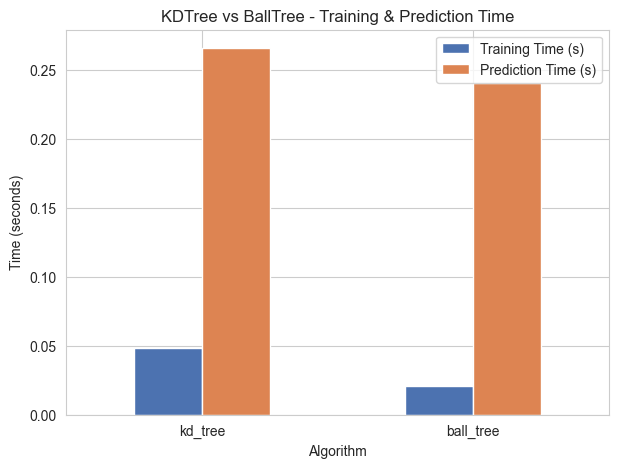

In [17]:
tree_df[["Training Time (s)", "Prediction Time (s)"]].plot(kind="bar", figsize=(7, 5), color=["#4C72B0", "#DD8452"])
plt.title("KDTree vs BallTree - Training & Prediction Time")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=0)
plt.show()

In [18]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

start = time.time()
grid_search.fit(X_train_std, y_train)
grid_time = time.time() - start

print("Best parameters (GridSearchCV):", grid_search.best_params_)
print("Best cross-validated accuracy:", grid_search.best_score_)
print(f"GridSearchCV took {grid_time:.2f} seconds")

Best parameters (GridSearchCV): {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best cross-validated accuracy: 0.9226086956521738
GridSearchCV took 9.71 seconds


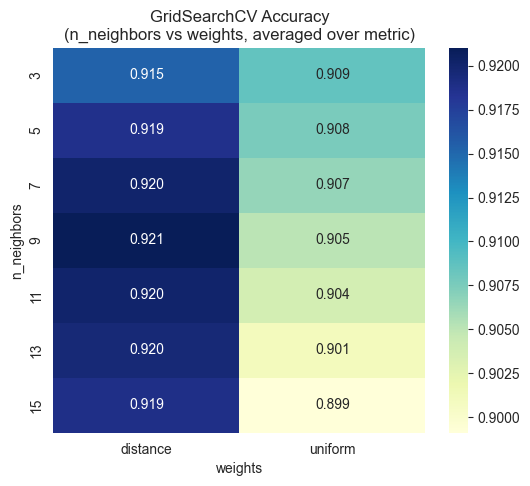

In [29]:
cv_results = pd.DataFrame(grid_search.cv_results_)
pivot = cv_results.pivot_table(
    index="param_n_neighbors", columns="param_weights", values="mean_test_score", aggfunc="mean"
)

plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("GridSearchCV Accuracy\n(n_neighbors vs weights, averaged over metric)")
plt.ylabel("n_neighbors")
plt.xlabel("weights")
plt.show()

In [20]:
from scipy.stats import randint

param_dist = {
    "n_neighbors": randint(1, 31),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "chebyshev"],
}

random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

start = time.time()
random_search.fit(X_train_std, y_train)
random_time = time.time() - start

print("Best parameters (RandomizedSearchCV):", random_search.best_params_)
print("Best cross-validated accuracy:", random_search.best_score_)
print(f"RandomizedSearchCV took {random_time:.2f} seconds")

Best parameters (RandomizedSearchCV): {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Best cross-validated accuracy: 0.9220289855072463
RandomizedSearchCV took 2.78 seconds


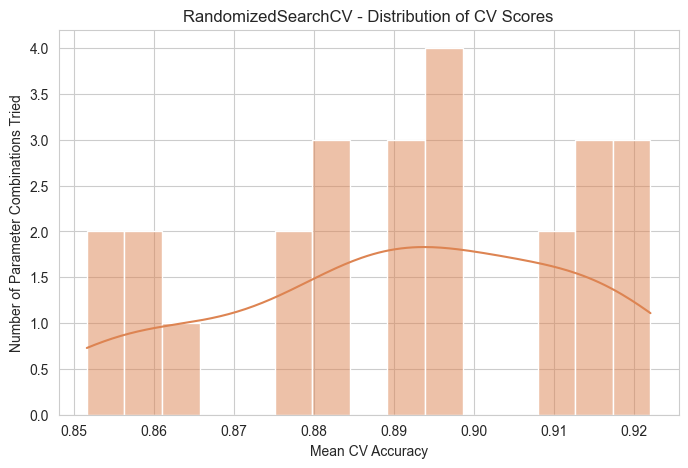

In [21]:
random_cv_results = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(8, 5))
sns.histplot(random_cv_results["mean_test_score"], bins=15, kde=True, color="#DD8452")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Number of Parameter Combinations Tried")
plt.title("RandomizedSearchCV - Distribution of CV Scores")
plt.show()

In [22]:
search_comparison = pd.DataFrame({
    "Method": ["GridSearchCV", "RandomizedSearchCV"],
    "Best CV Accuracy": [grid_search.best_score_, random_search.best_score_],
    "Time Taken (s)": [grid_time, random_time],
    "Combinations Tried": [len(cv_results), len(random_cv_results)],
}).set_index("Method")

search_comparison

,Best CV Accuracy,Time Taken (s),Combinations Tried
Method,,,
GridSearchCV,0.922609,9.708375,28
RandomizedSearchCV,0.922029,2.782963,25


In [23]:
best_knn = KNeighborsClassifier(**grid_search.best_params_)

start = time.time()
best_knn.fit(X_train_std, y_train)
train_times["KNN (Tuned)"] = time.time() - start

res, y_pred, y_proba = evaluate_model("KNN (Tuned)", best_knn, X_test_std, y_test)
results_list.append(res)
predictions["KNN (Tuned)"] = (y_pred, y_proba)

results_df = pd.DataFrame(results_list).set_index("Model")
results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC,Prediction Time (s)
Model,,,,,,
GaussianNB,0.825369,0.707718,0.949339,0.810913,0.936771,0.002705
MultinomialNB,0.900087,0.947230,0.790749,0.861945,0.961433,0.000437
BernoulliNB,0.904431,0.911483,0.839207,0.873853,0.962285,0.001410
KNN,0.899218,0.878924,0.863436,0.871111,0.950853,0.576006
KNN (Tuned),0.925282,0.944444,0.861233,0.900922,0.973636,0.081988


In [24]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}
X_all_std = scaler.fit_transform(X)
X_all_mm = mm_scaler.fit_transform(X)

cv_scores["GaussianNB"] = cross_val_score(GaussianNB(), X_all_std, y, cv=cv_strategy, scoring="accuracy")
cv_scores["MultinomialNB"] = cross_val_score(MultinomialNB(), X_all_mm, y, cv=cv_strategy, scoring="accuracy")
cv_scores["BernoulliNB"] = cross_val_score(BernoulliNB(), X_all_std, y, cv=cv_strategy, scoring="accuracy")
cv_scores["KNN (Tuned)"] = cross_val_score(KNeighborsClassifier(**grid_search.best_params_), X_all_std, y, cv=cv_strategy, scoring="accuracy")

for name, scores in cv_scores.items():
    print(f"{name}: mean accuracy = {scores.mean():.4f}, std = {scores.std():.4f}")

GaussianNB: mean accuracy = 0.8155, std = 0.0091
MultinomialNB: mean accuracy = 0.8876, std = 0.0047
BernoulliNB: mean accuracy = 0.9022, std = 0.0075
KNN (Tuned): mean accuracy = 0.9257, std = 0.0073


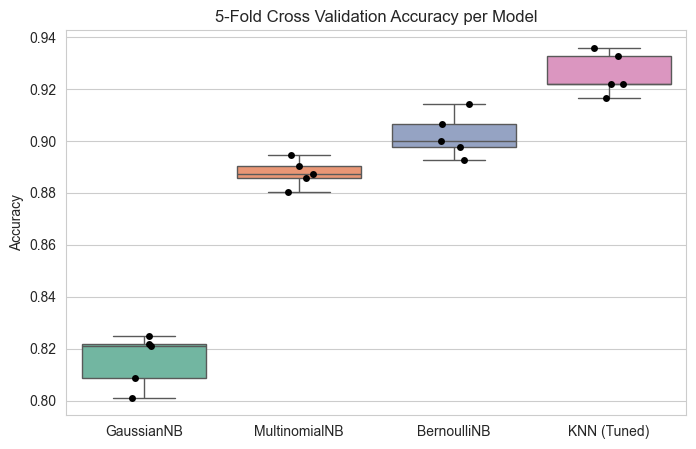

In [25]:
cv_df = pd.DataFrame(cv_scores)

plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_df, palette="Set2")
sns.stripplot(data=cv_df, color="black", size=5, jitter=True)
plt.title("5-Fold Cross Validation Accuracy per Model")
plt.ylabel("Accuracy")
plt.show()

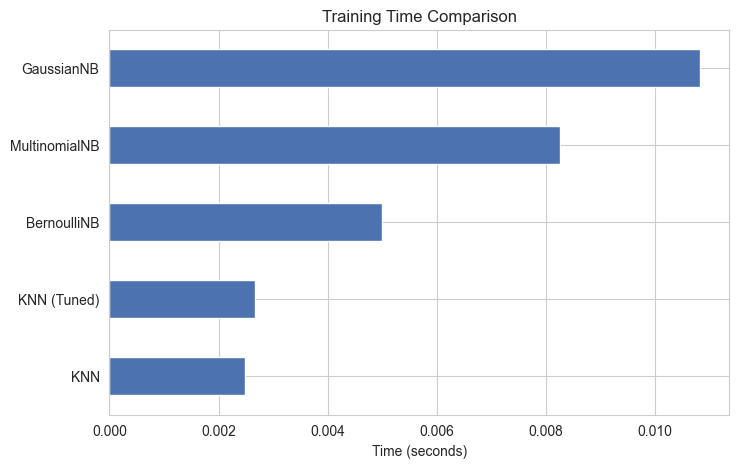

In [ ]:
train_time_df = pd.Series(train_times, name="Training Time (s)").sort_values()

plt.figure(figsize=(8, 5))
train_time_df.plot(kind="barh", color="#4C72B0")
plt.xlabel("Time (seconds)")
plt.title("Training Time Comparison")
plt.show()

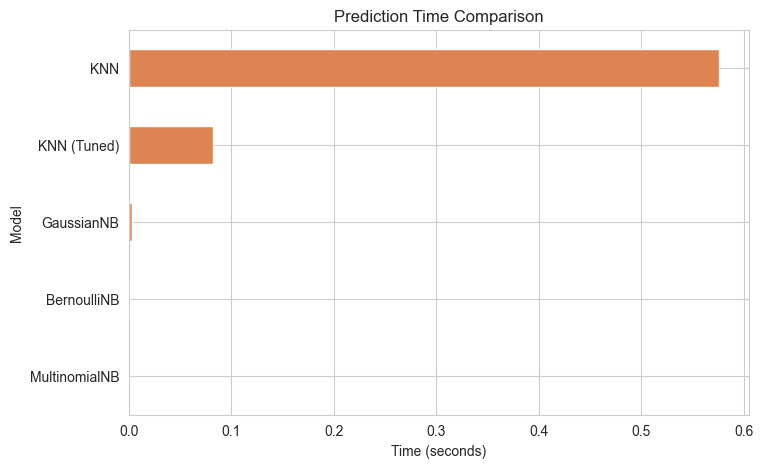

In [27]:
pred_time_df = results_df["Prediction Time (s)"].sort_values()

plt.figure(figsize=(8, 5))
pred_time_df.plot(kind="barh", color="#DD8452")
plt.xlabel("Time (seconds)")
plt.title("Prediction Time Comparison")
plt.show()

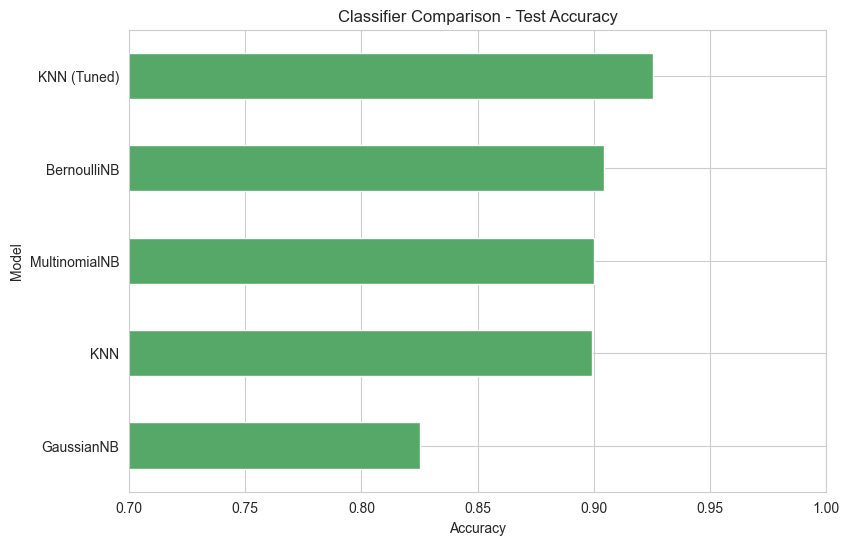

,Accuracy,Precision,Recall,F1-score,ROC-AUC,Prediction Time (s)
Model,,,,,,
KNN (Tuned),0.925282,0.944444,0.861233,0.900922,0.973636,0.081988
BernoulliNB,0.904431,0.911483,0.839207,0.873853,0.962285,0.001410
MultinomialNB,0.900087,0.947230,0.790749,0.861945,0.961433,0.000437
KNN,0.899218,0.878924,0.863436,0.871111,0.950853,0.576006
GaussianNB,0.825369,0.707718,0.949339,0.810913,0.936771,0.002705


In [28]:
plt.figure(figsize=(9, 6))
results_df["Accuracy"].sort_values().plot(kind="barh", color="#55A868")
plt.xlabel("Accuracy")
plt.title("Classifier Comparison - Test Accuracy")
plt.xlim(0.7, 1.0)
plt.show()

results_df.sort_values("Accuracy", ascending=False)